# 03 — Inference

Loads the trained model saved by `02_train_and_evaluate.ipynb` and runs inference on
user-specified images.

Two input options are provided:

| Option | Description |
|--------|-------------|
| **A**  | Pick images by index from the saved test split (`notebooks/data/test.npz`) |
| **B**  | Load your own 64×64 grayscale images from file paths |

> **Pre-requisite:** run `02_train_and_evaluate.ipynb` first so that
> `notebooks/models/detector.keras` exists.

In [31]:
%pip install matplotlib --quiet
import sys, os

project_root = (
    os.path.abspath('..')
    if os.path.basename(os.getcwd()) == 'notebooks'
    else os.path.abspath('.')
)
if project_root not in sys.path:
    sys.path.insert(0, project_root)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf

In [33]:
# ── configuration ──────────────────────────────────────────────────────────
IMG_SIZE = 64

_nb_dir    = (
    os.path.join(os.getcwd(), 'notebooks')
    if os.path.isdir(os.path.join(os.getcwd(), 'notebooks'))
    else os.getcwd()
)
MODEL_PATH = os.path.join(_nb_dir, 'models', 'detector.keras')
DATA_DIR   = os.path.join(_nb_dir, 'data')
# ───────────────────────────────────────────────────────────────────────────

## 1. Load Model

`compile=False` skips loss deserialisation — for inference we only need the weights
and architecture, not the `HungarianLoss` object.

In [34]:
# Register custom layer so Keras can deserialise the saved model
@tf.keras.utils.register_keras_serializable(package='hungarian_loss')
class LearnedQueries(tf.keras.layers.Layer):
    def __init__(self, num_queries, d_model, **kwargs):
        super().__init__(**kwargs)
        self.num_queries = num_queries
        self.d_model = d_model

    def build(self, input_shape):
        self.queries = self.add_weight(
            name='object_queries',
            shape=(self.num_queries, self.d_model),
            initializer='glorot_uniform',
            trainable=True,
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        return tf.tile(self.queries[None], [batch, 1, 1])

    def get_config(self):
        config = super().get_config()
        config.update({'num_queries': self.num_queries, 'd_model': self.d_model})
        return config


In [35]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f'Loaded model from {MODEL_PATH}')
print(f'Input shape : {model.input_shape}')
print(f'Output shape: {model.output_shape}')

Loaded model from /Users/mykola/Projects/hungarian-loss/notebooks/models/detector.keras
Input shape : (None, 64, 64, 1)
Output shape: (None, 3, 4)


## 2. Inference Helper

In [36]:
def _to_corner(cx, cy, w, h, img_size):
    """Convert centre [cx,cy,w,h] (normalised) to pixel corner coords.

    Subtracts 0.5 to account for matplotlib's pixel-centre convention:
    imshow centres pixel [r,c] at coordinate (c, r), so a numpy slice
    x:x+w occupies (x-0.5) … (x+w-0.5) in data coordinates.
    """
    px = (cx - w / 2) * img_size - 0.5
    py = (cy - h / 2) * img_size - 0.5
    return px, py, w * img_size, h * img_size


def predict_image(model, img_array):
    """
    Run inference on a single image.

    Parameters
    ----------
    img_array : np.ndarray
        Grayscale image of shape (H, W) or (H, W, 1), values in [0, 1].

    Returns
    -------
    np.ndarray  shape (MAX_OBJ, 4)  — predicted boxes [cx, cy, w, h] in [0, 1]
    """
    img = np.array(img_array, dtype=np.float32)
    if img.ndim == 2:
        img = img[..., np.newaxis]
    if img.max() > 1.0:
        img = img / 255.0
    return model.predict(img[np.newaxis], verbose=0)[0]   # (MAX_OBJ, 4)


def draw_boxes(ax, image, pred_boxes, gt_boxes=None, img_size=64, title=''):
    ax.imshow(image[:, :, 0] if image.ndim == 3 else image,
              cmap='gray', vmin=0, vmax=1)
    if gt_boxes is not None:
        for cx, cy, w, h in gt_boxes:
            if w == 0:      # skip zero-padded slots
                continue
            px, py, pw, ph = _to_corner(cx, cy, w, h, img_size)
            ax.add_patch(patches.Rectangle(
                (px, py), pw, ph,
                linewidth=1.5, edgecolor='lime', facecolor='none'
            ))
    for cx, cy, w, h in pred_boxes:
        px, py, pw, ph = _to_corner(cx, cy, w, h, img_size)
        ax.add_patch(patches.Rectangle(
            (px, py), pw, ph,
            linewidth=1.5, edgecolor='red', facecolor='none', linestyle='--'
        ))
    ax.set_title(title, fontsize=8)
    ax.axis('off')

## Option A — Images from the Saved Test Split

Change `TEST_INDICES` to inspect any images you like.

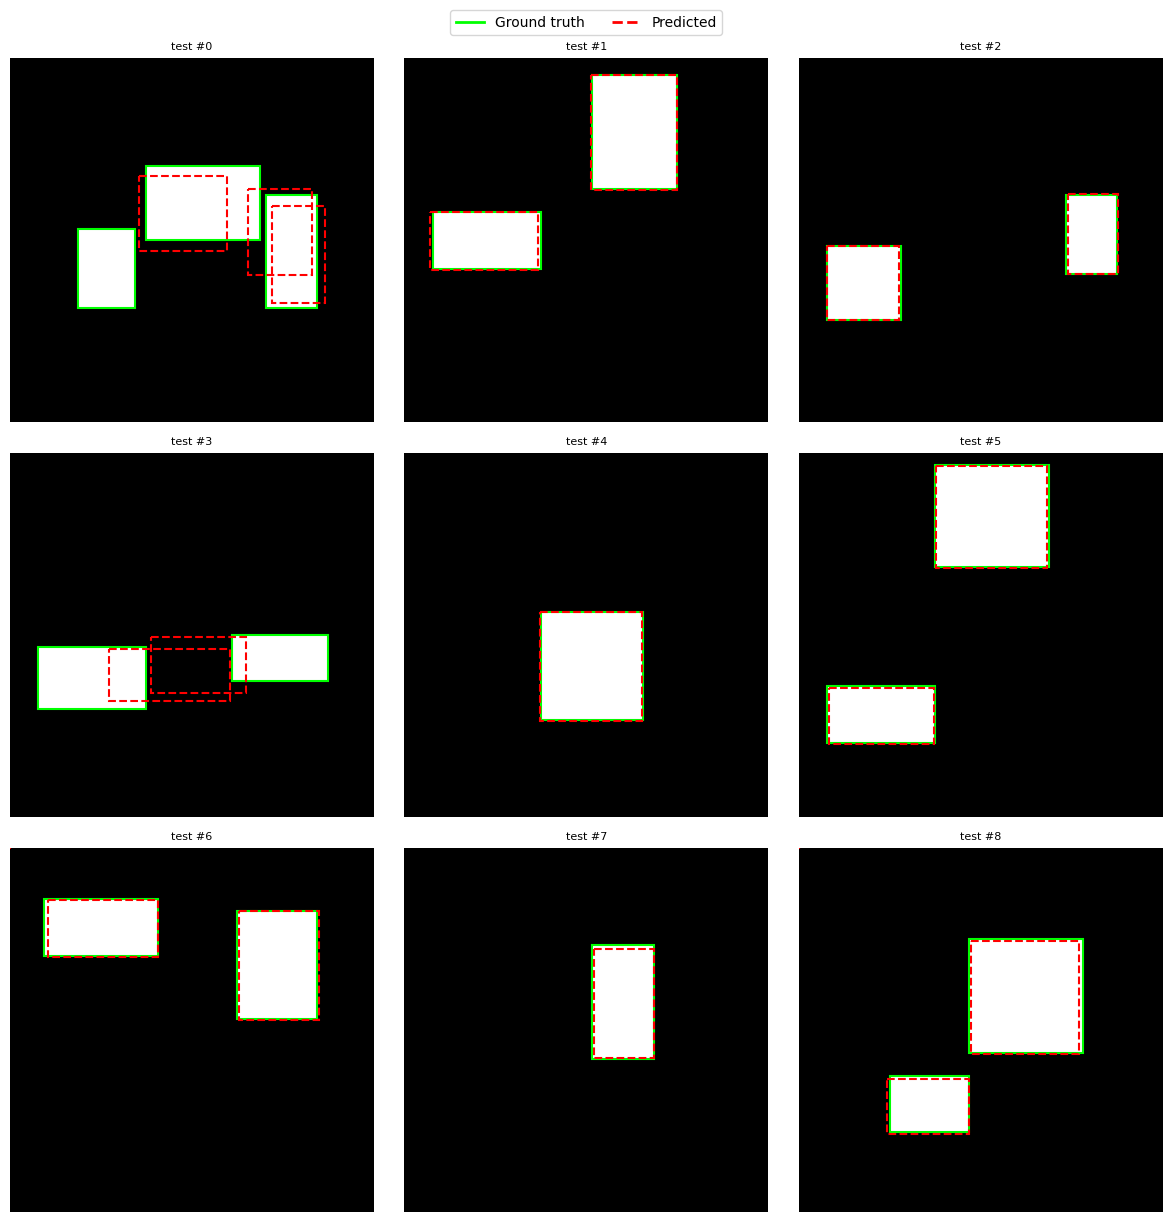

In [37]:
# ── edit these indices ─────────────────────────────────────────────────────
TEST_INDICES = [0, 1, 2, 3, 4, 5, 6, 7, 8]
# ───────────────────────────────────────────────────────────────────────────

d = np.load(os.path.join(DATA_DIR, 'test.npz'))
X_test, y_test = d['images'], d['labels']

cols = min(3, len(TEST_INDICES))
rows = (len(TEST_INDICES) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).flat

for ax, idx in zip(axes, TEST_INDICES):
    preds = predict_image(model, X_test[idx])
    draw_boxes(ax, X_test[idx], preds, gt_boxes=y_test[idx],
               title=f'test #{idx}')

for ax in list(axes)[len(TEST_INDICES):]:
    ax.axis('off')

from matplotlib.lines import Line2D
fig.legend(
    handles=[
        Line2D([0], [0], color='lime', linewidth=2, label='Ground truth'),
        Line2D([0], [0], color='red',  linewidth=2, linestyle='--', label='Predicted'),
    ],
    loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=10,
)
plt.tight_layout()
plt.show()

## Option B — Custom Image Files

Provide a list of paths to **64×64 grayscale** PNG or JPEG files.  
If your images are a different size, resize them to 64×64 before passing.

In [38]:
# ── edit these paths ───────────────────────────────────────────────────────
IMAGE_PATHS = [
    # 'path/to/image1.png',
    # 'path/to/image2.jpg',
]
# ───────────────────────────────────────────────────────────────────────────

if not IMAGE_PATHS:
    print('No paths specified in IMAGE_PATHS — skipping Option B.')
else:
    cols = min(3, len(IMAGE_PATHS))
    rows = (len(IMAGE_PATHS) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flat

    for ax, path in zip(axes, IMAGE_PATHS):
        raw = plt.imread(path)
        if raw.ndim == 3:
            raw = raw.mean(axis=-1)          # convert RGB -> grayscale
        img = raw.astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0
        img = img[..., np.newaxis]           # (H, W, 1)
        preds = predict_image(model, img)
        draw_boxes(ax, img, preds, title=os.path.basename(path))

    for ax in list(axes)[len(IMAGE_PATHS):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

No paths specified in IMAGE_PATHS — skipping Option B.
